In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,n_features=3,centers=4)

In [3]:
X

array([[ 0.70042784,  1.04994747, -2.10089807],
       [-5.7952478 , -3.65500896,  3.06564057],
       [-1.06170702, -1.25246097, -6.37292674],
       ...,
       [ 1.23267244,  1.7666575 , -2.3859503 ],
       [ 2.15715275,  0.5106229 , -3.92827036],
       [ 2.95949784, -0.29426576, -2.57444336]], shape=(1000, 3))

In [4]:
y

array([0, 2, 1, 2, 2, 3, 3, 3, 0, 0, 0, 3, 2, 3, 2, 0, 2, 0, 2, 0, 0, 2,
       1, 1, 2, 2, 3, 1, 2, 1, 0, 0, 2, 3, 3, 1, 0, 3, 1, 0, 1, 3, 3, 0,
       3, 2, 1, 2, 3, 0, 3, 2, 2, 3, 3, 0, 0, 3, 0, 3, 1, 1, 2, 1, 2, 2,
       3, 3, 2, 2, 2, 0, 2, 1, 3, 1, 3, 3, 3, 1, 0, 1, 2, 2, 3, 0, 3, 3,
       1, 2, 0, 2, 0, 1, 1, 2, 0, 3, 1, 2, 3, 0, 0, 0, 2, 0, 3, 0, 1, 0,
       2, 3, 0, 3, 3, 1, 0, 3, 2, 3, 1, 0, 0, 3, 0, 1, 0, 0, 3, 3, 0, 0,
       1, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 0, 3, 3, 3, 0, 2, 1, 1, 1, 2, 0,
       2, 0, 0, 3, 3, 1, 3, 2, 2, 3, 0, 0, 2, 2, 2, 3, 1, 1, 1, 1, 0, 0,
       0, 3, 1, 0, 3, 1, 1, 3, 1, 0, 3, 2, 0, 0, 1, 2, 0, 0, 0, 2, 1, 3,
       2, 0, 3, 3, 0, 3, 1, 2, 2, 3, 0, 2, 1, 1, 3, 1, 3, 1, 2, 3, 1, 2,
       1, 0, 1, 3, 1, 2, 2, 1, 1, 2, 1, 2, 3, 3, 2, 2, 0, 3, 0, 0, 2, 1,
       3, 0, 2, 3, 2, 1, 3, 1, 1, 0, 3, 0, 0, 0, 2, 2, 2, 3, 0, 0, 3, 1,
       2, 2, 1, 0, 1, 1, 3, 0, 3, 2, 0, 1, 2, 0, 2, 0, 0, 1, 0, 2, 1, 1,
       1, 2, 3, 1, 2, 1, 3, 3, 0, 3, 0, 2, 2, 1, 3,

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


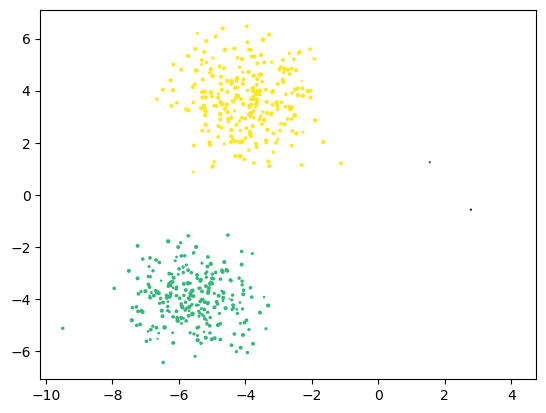

In [5]:
plt.scatter(X[:,0],X[:,1],X[:,2],c=y)

In [6]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [7]:
#Train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [8]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [9]:
#apply kmeans clustering algo
from sklearn.cluster import KMeans

In [10]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[2099.9999999999995,
 922.4750243325152,
 332.9097566938757,
 197.31010324430508,
 179.17550650323875,
 166.529031928115,
 155.85266607542312,
 144.44469948442105,
 133.94334596611793,
 124.37312313072954]

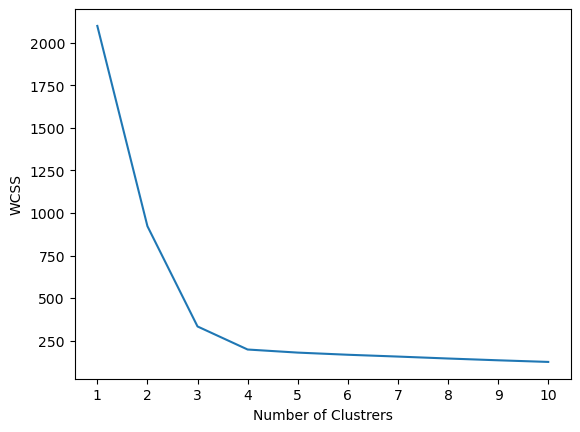

In [12]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [13]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [14]:
kmeans.fit_predict(X_train_scaled)

array([2, 0, 1, 1, 0, 1, 2, 1, 1, 0, 1, 1, 1, 1, 2, 0, 1, 1, 2, 2, 1, 0,
       2, 0, 2, 1, 1, 1, 1, 0, 0, 0, 1, 2, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1,
       2, 1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 0,
       2, 1, 1, 0, 2, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 2, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 2, 1, 2, 0, 0, 1,
       1, 0, 1, 0, 2, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 2, 2, 1, 0,
       2, 2, 0, 0, 1, 2, 2, 1, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 2, 2,
       2, 0, 0, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1, 0, 1, 0, 0, 1, 1,
       2, 2, 1, 1, 1, 1, 2, 0, 0, 1, 2, 1, 0, 1, 1, 0, 1, 2, 0, 1, 0, 2,
       1, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 2, 0, 2, 1, 1, 2, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 2, 1, 2, 2, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 1, 0, 2, 1, 1, 1, 0, 1, 0, 2,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 0, 1, 1, 1, 1, 0, 1, 2, 1,
       1, 1, 1, 1, 2, 1, 2, 1, 0, 0, 0, 1, 0, 1, 1,

In [15]:
y_pred=kmeans.predict(X_test_scaled)

In [16]:
y_pred

array([1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 0, 0, 1, 1, 2, 1, 1, 2, 0,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 1, 2,
       0, 1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 1, 2, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 0, 2,
       2, 1, 1, 1, 2, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 0, 0, 1, 2, 0, 0, 1,
       0, 2, 1, 1, 1, 1, 0, 0, 2, 1, 0, 1, 0, 1, 2, 0, 0, 1, 0, 2, 1, 2,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 2, 2, 2, 0, 1, 1, 2, 1, 0, 0, 1, 2, 0,
       1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 0, 1, 1, 2, 1, 1, 2, 0, 1,
       2, 2, 1, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 1, 0, 1, 2, 1, 2, 1,
       0, 2, 1, 1, 0, 1, 0, 1, 2, 1, 1, 0, 2, 2, 2, 1, 0, 2, 1, 1, 0, 1,
       1, 2, 1, 1, 1, 2, 2, 1, 0, 0, 2, 1, 2, 0, 0, 2, 0, 2, 1, 1, 2, 1,
       0, 2, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 0,
       1, 1, 1, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 1], d

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


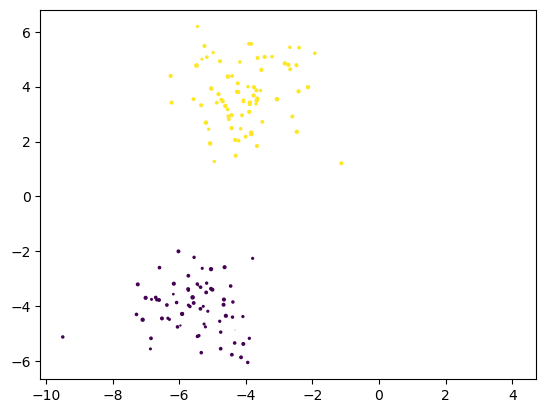

In [17]:
plt.scatter(X_test[:,0],X_test[:,1],X_test[:,2],c=y_pred)

In [18]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [19]:
from kneed import KneeLocator

In [20]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [21]:
print(kl.elbow)

3


In [22]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [23]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [24]:
silhouette_coefficients

[0.5455850106659035,
 0.6754506081309654,
 0.6127532589191896,
 0.4810598457606987,
 0.3798210759114711,
 0.35233577695429036,
 0.2804164458155346,
 0.2791311366596026,
 0.3004804403005181]

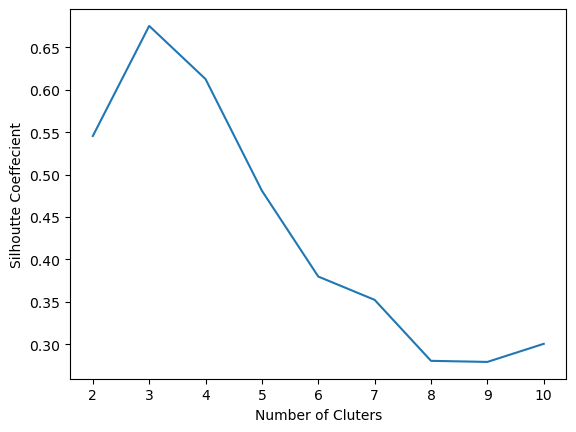

In [25]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()